In [13]:
import pandas as pd
import numpy as np
import json

In [14]:
def get_plot_data(df):
    aug_rates = df["augmentation_rate"].unique().tolist()
    means = []
    vars = [] # variances
    lows = [] # lower bound of confidence interval
    highs = [] # upper bound of confidence interval

    for aug_rate in aug_rates:
        values = df[df["augmentation_rate"] == aug_rate]["code_similarity"].tolist()
        mean = np.mean(values)
        variance = np.var(values)
        std = np.std(values)
        ci = 1.96 * std / np.sqrt(len(values))

        means.append(mean)
        vars.append(variance)
        lows.append(mean - ci)
        highs.append(mean + ci)

    return means, vars, lows, highs

In [15]:
with open("results/Gemini-calculator-2024-10-24-00-00-00.json", 'r') as f:
    gemini_data_json = json.load(f)

gemini_data = pd.DataFrame(gemini_data_json["measurements"])

with open("results/OpenAI-calculator-2024-11-18-17-48-51.json", 'r') as f:
    openai_data_json = json.load(f)

openai_data = pd.DataFrame(openai_data_json["measurements"])

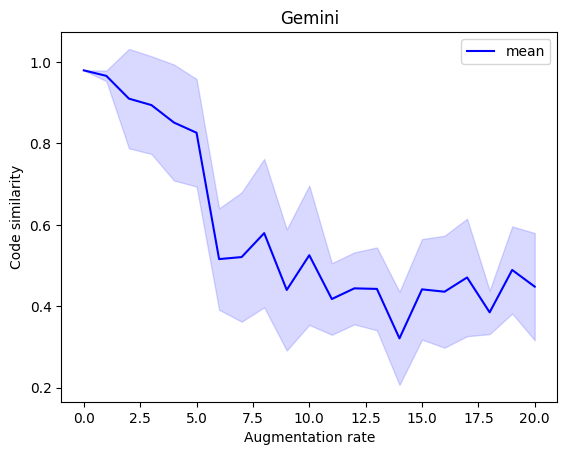

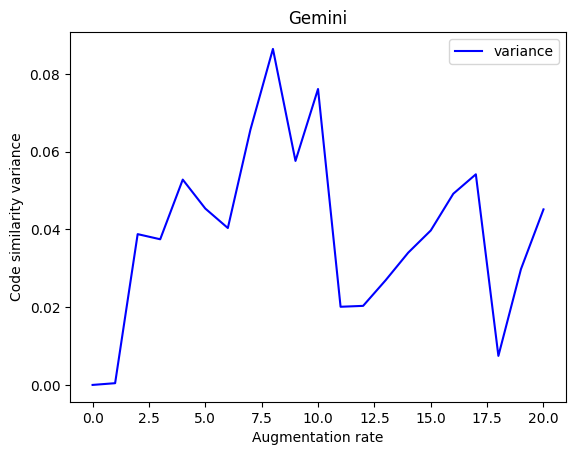

In [16]:
import matplotlib.pyplot as plt

means, vars, lows, highs = get_plot_data(gemini_data)

plt.figure()
plt.plot(means,'-b', label='mean')
plt.fill_between(list(range(len(means))), lows, highs, color="b", alpha=0.15)
plt.xlabel("Augmentation rate")
plt.ylabel("Code similarity")
plt.legend();
plt.title("Gemini");


plt.figure()
plt.plot(vars,'-b', label='variance')
plt.xlabel("Augmentation rate")
plt.ylabel("Code similarity variance")
plt.legend();
plt.title("Gemini");


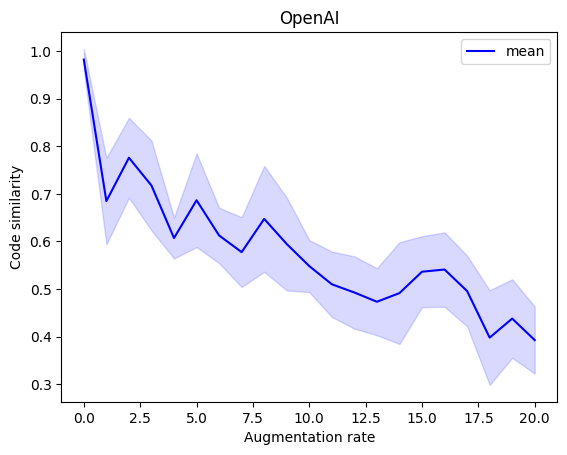

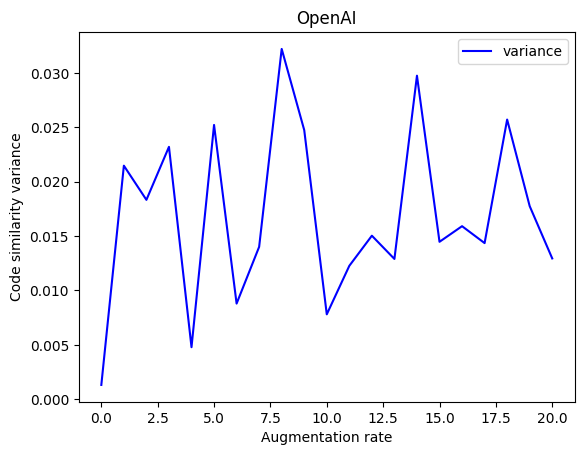

In [17]:
import matplotlib.pyplot as plt

means, vars, lows, highs = get_plot_data(openai_data)

plt.figure()
plt.plot(means,'-b', label='mean')
plt.fill_between(list(range(len(means))), lows, highs, color="b", alpha=0.15)
plt.xlabel("Augmentation rate")
plt.ylabel("Code similarity")
plt.legend();
plt.title("OpenAI");


plt.figure()
plt.plot(vars,'-b', label='variance')
plt.xlabel("Augmentation rate")
plt.ylabel("Code similarity variance")
plt.legend();
plt.title("OpenAI");
